In [30]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
spark = SparkSession.builder.appName("Read Parquet").getOrCreate()
# read in all the data across the times
year_2026_01 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-01.parquet")
year_2026_02 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-02.parquet")
year_2026_03 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-03.parquet")
year_2026_04 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-04.parquet")
year_2026_05 = spark.read.parquet("data/year-2026/yellow_tripdata_2026-05.parquet")
data = year_2026_01.union(year_2026_02).union(year_2026_03).union(year_2026_04).union(year_2026_05)
data.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



# Calculating trip duration and revenue per minute

In [31]:
import geopandas as gpd
taxi_zones = gpd.read_file('data/taxi_zones/taxi_zones.shp')
print(taxi_zones.dtypes)
taxi_zones.head()

OBJECTID         int32
Shape_Leng     float64
Shape_Area     float64
zone               str
LocationID       int32
borough            str
geometry      geometry
dtype: object


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [32]:
raw_weather_data = spark.read.csv("data/weather.csv", header=True, inferSchema=True)
print(raw_weather_data.columns)

['STATION', 'NAME', 'DATE', 'AWND', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'TOBS', 'WDF2', 'WDF5', 'WESD', 'WESF', 'WSF2', 'WSF5', 'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT06', 'WT08', 'WT09', 'WT11']


In [33]:
raw_weather_data = raw_weather_data.filter(
    F.col('STATION').isin(['USW00014732', 'USW00094789'])  # LaGuardia + JFK
)

In [34]:
weather_df = raw_weather_data.filter(raw_weather_data['NAME'].contains('LAGUARDIA')).select('DATE', 'PRCP', 'SNOW', 'TMAX', 'TMIN')
weather_df = weather_df.withColumn('TAVG', (F.col('TMAX') + F.col('TMIN')) / 2)
weather_df.show()

+----------+----+----+----+----+----+
|      DATE|PRCP|SNOW|TMAX|TMIN|TAVG|
+----------+----+----+----+----+----+
|2026-01-01| 0.0| 0.0|  36|  23|29.5|
|2026-01-02| 0.0| 0.0|  30|  20|25.0|
|2026-01-03| 0.0| 0.0|  31|  24|27.5|
|2026-01-04| 0.0| 0.0|  35|  26|30.5|
|2026-01-05| 0.0| 0.0|  38|  30|34.0|
|2026-01-06|0.01| 0.0|  39|  35|37.0|
|2026-01-07|0.01| 0.0|  48|  36|42.0|
|2026-01-08| 0.0| 0.0|  50|  37|43.5|
|2026-01-09| 0.0| 0.0|  54|  35|44.5|
|2026-01-10|0.46| 0.0|  53|  38|45.5|
|2026-01-11|0.02| 0.0|  47|  34|40.5|
|2026-01-12| 0.0| 0.0|  41|  32|36.5|
|2026-01-13| 0.0| 0.0|  47|  37|42.0|
|2026-01-14| 0.0| 0.0|  51|  42|46.5|
|2026-01-15| 0.0| 0.0|  46|  25|35.5|
|2026-01-16| 0.0| 0.0|  34|  22|28.0|
|2026-01-17|0.17| 1.4|  40|  31|35.5|
|2026-01-18|0.26| 1.5|  35|  31|33.0|
|2026-01-19| 0.0| 0.0|  33|  24|28.5|
|2026-01-20| 0.0| 0.0|  27|  17|22.0|
+----------+----+----+----+----+----+
only showing top 20 rows


In [35]:
daily_aggregated_data = data
daily_aggregated_data = (
    data
    .groupBy(
        F.to_date("tpep_pickup_datetime").alias("date"),
        "PULocationID"
    )
    .agg(
        F.sum("total_amount").alias("daily_revenue")
    )
    .orderBy("date", "PULocationID")
).sort('PULocationID', 'date')
print(daily_aggregated_data.count())
daily_aggregated_data.show()

36765
+----------+------------+------------------+
|      date|PULocationID|     daily_revenue|
+----------+------------+------------------+
|2026-01-01|           1|3848.2300000000005|
|2026-01-02|           1|           3044.13|
|2026-01-03|           1|2981.3399999999997|
|2026-01-04|           1| 4814.719999999999|
|2026-01-05|           1|2216.2799999999997|
|2026-01-06|           1|2014.4499999999998|
|2026-01-07|           1|            723.88|
|2026-01-08|           1|            587.96|
|2026-01-09|           1| 802.8199999999999|
|2026-01-10|           1|            885.02|
|2026-01-11|           1|             809.4|
|2026-01-12|           1|           1045.06|
|2026-01-13|           1|           1406.75|
|2026-01-14|           1|           1382.54|
|2026-01-15|           1|           2014.62|
|2026-01-16|           1|            1414.9|
|2026-01-17|           1|1278.1000000000001|
|2026-01-18|           1|1118.5900000000001|
|2026-01-19|           1|2250.8100000000004|
|202

In [36]:
def calculate_expected_daily_revenue(
    aggregated_data,
    geospatial_data
):
    """
    Calculate expected daily revenue for every location based on
    the average daily revenue of its geographic neighbors.

    If a location has no geographic neighbors, or no neighbor revenue
    for a particular date, the city-wide average revenue for that date
    is used as the fallback.

    Args:
        aggregated_data (Spark DataFrame):
            Spark DataFrame containing:
            [date, PULocationID, daily_revenue]

        geospatial_data (GeoDataFrame):
            GeoPandas GeoDataFrame containing:
            [OBJECTID, geometry]

    Returns:
        Spark DataFrame:
            The original aggregated_data with an additional column:
            [expected_daily_revenue]
    """

    # ---------------------------------------------------------
    # 1. Build geographic neighbor relationships once
    # ---------------------------------------------------------

    neighbor_rows = []

    for _, zone in geospatial_data.iterrows():

        location_id = zone["OBJECTID"]
        zone_geometry = zone["geometry"]

        neighbor_mask = geospatial_data.geometry.touches(zone_geometry)

        neighbor_ids = geospatial_data.loc[
            neighbor_mask,
            "OBJECTID"
        ].tolist()

        for neighbor_id in neighbor_ids:
            neighbor_rows.append(
                (location_id, neighbor_id)
            )

    neighbor_df = spark.createDataFrame(
        neighbor_rows,
        ["PULocationID", "neighbor_id"]
    )

    # ---------------------------------------------------------
    # 2. Calculate city-wide daily average once
    # ---------------------------------------------------------

    city_daily_avg = (
        aggregated_data
        .groupBy("date")
        .agg(
            F.avg("daily_revenue").alias("city_avg_daily_revenue")
        )
    )

    # ---------------------------------------------------------
    # 3. Get daily revenue for every location's neighbors
    # ---------------------------------------------------------

    neighbor_daily_revenue = (
        neighbor_df
        .join(
            aggregated_data,
            neighbor_df["neighbor_id"]
            == aggregated_data["PULocationID"],
            "inner"
        )
        .groupBy(
            neighbor_df["PULocationID"],
            aggregated_data["date"]
        )
        .agg(
            F.avg("daily_revenue").alias(
                "expected_daily_revenue"
            )
        )
    )

    # ---------------------------------------------------------
    # 4. Join expected revenue back onto original data
    # ---------------------------------------------------------

    result = (
        aggregated_data
        .join(
            neighbor_daily_revenue,
            on=["PULocationID", "date"],
            how="left"
        )
        .join(
            city_daily_avg,
            on="date",
            how="left"
        )
        .withColumn(
            "expected_daily_revenue",
            F.coalesce(
                F.col("expected_daily_revenue"),
                F.col("city_avg_daily_revenue")
            )
        )
        .drop("city_avg_daily_revenue")
        .orderBy("PULocationID", "date")
    )

    return result

In [37]:
performance_stats = calculate_expected_daily_revenue(daily_aggregated_data, taxi_zones)
performance_stats.show()

+----------+------------+------------------+----------------------+
|      date|PULocationID|     daily_revenue|expected_daily_revenue|
+----------+------------+------------------+----------------------+
|2026-01-01|           1|3848.2300000000005|    14560.467903225826|
|2026-01-02|           1|           3044.13|     12211.57793388433|
|2026-01-03|           1|2981.3399999999997|    12886.853153527007|
|2026-01-04|           1| 4814.719999999999|    11649.236058091332|
|2026-01-05|           1|2216.2799999999997|     11917.76881147546|
|2026-01-06|           1|2014.4499999999998|    12539.380040816339|
|2026-01-07|           1|            723.88|     13247.79028925621|
|2026-01-08|           1|            587.96|    14165.054485596725|
|2026-01-09|           1| 802.8199999999999|    14537.318760330603|
|2026-01-10|           1|            885.02|    16326.816639004172|
|2026-01-11|           1|             809.4|    13544.410041666693|
|2026-01-12|           1|           1045.06|    

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


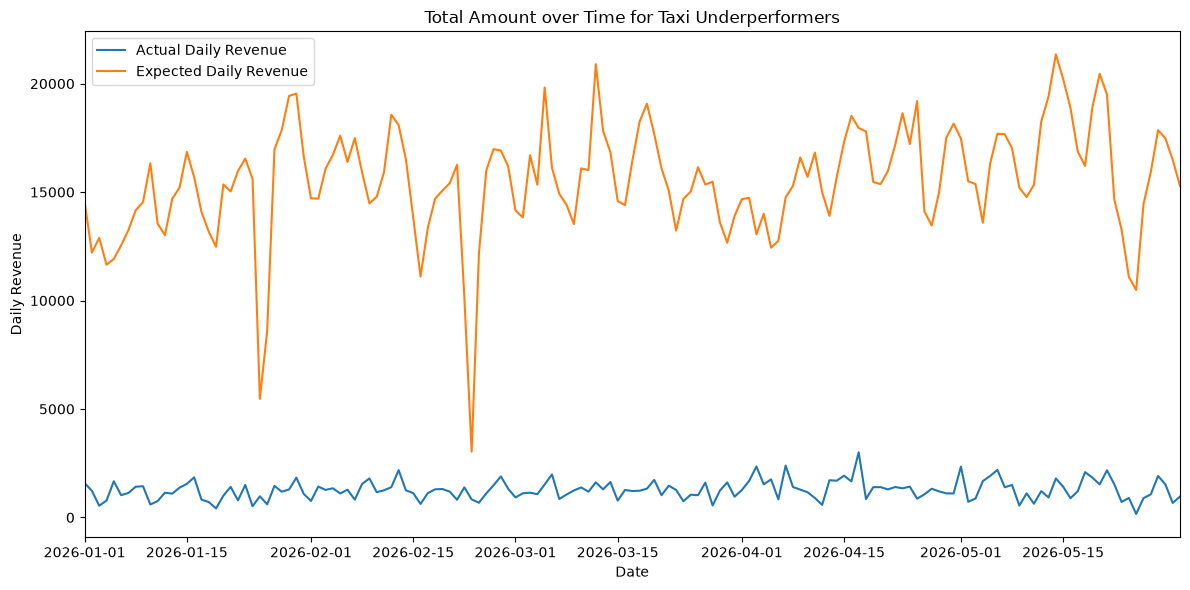

In [59]:
import pandas as pd
expected_performance = performance_stats.filter(F.col("PULocationID") == 119)  # Example PULocationID
# Convert PySpark DataFrame to Pandas for plotting
taxi_underperformers_sub = expected_performance.select("date", "daily_revenue", 'expected_daily_revenue') \
    .orderBy("date") \
    .toPandas()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(taxi_underperformers_sub["date"], taxi_underperformers_sub["daily_revenue"], label="Actual Daily Revenue")
plt.plot(taxi_underperformers_sub["date"], taxi_underperformers_sub["expected_daily_revenue"], label="Expected Daily Revenue")
plt.xlim(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-05-31'))
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.title("Total Amount over Time for Taxi Underperformers")
plt.legend()
plt.tight_layout()
plt.show()

# Calculating underperformance to identify underperforming taxi zones

In [39]:
minutes_per_day = 24 * 60

revenue_per_min_df = (
    performance_stats
    .groupBy("PULocationID")
    .agg(
        (F.sum(F.coalesce(F.col("daily_revenue"), F.lit(0.0))) / F.lit(float(minutes_per_day))).alias("revenue_per_min"),
        (F.sum(F.coalesce(F.col("expected_daily_revenue"), F.lit(0.0))) / F.lit(float(minutes_per_day))).alias("expected_revenue_per_min")
    )
    .orderBy("PULocationID")
)
print(revenue_per_min_df.count())
revenue_per_min_df.show()

262


+------------+------------------+------------------------+
|PULocationID|   revenue_per_min|expected_revenue_per_min|
+------------+------------------+------------------------+
|           1| 175.1679583333333|       1625.111294709252|
|           2|1.7620694444444445|       8817.435840277862|
|           3| 61.04570833333334|      150.05107465277777|
|           4|1550.2027847222228|        4972.88015972222|
|           5|0.5002291666666666|      133.90013839030482|
|           6| 9.665187499999995|      285.90064305937256|
|           7| 982.1182152777776|       218.0837638888887|
|           8| 7.954381944444444|      1231.1421744331424|
|           9| 22.78847916666667|        48.3084658564815|
|          10|418.14806944444473|       206.3424930555555|
|          11|41.673006944444445|       250.2262916666667|
|          12|106.82911111111108|      2786.6290277777775|
|          13| 2788.796194444444|      110.62596828314658|
|          14|250.79528472222225|       68.1041770833333

In [55]:
revenue_per_min_df = revenue_per_min_df.withColumn(
    "underperformance_per_min",
    (F.col("expected_revenue_per_min") - F.col("revenue_per_min")) / F.col("expected_revenue_per_min") * 100  # Convert to percentage
)
# Count instances per PULocationID in the raw trip data
location_counts_df = (
    data
    .groupBy("PULocationID")
    .agg(F.count("*").alias("instance_count"))
)

# Keep only locations with at least 5000 instances
revenue_per_min_df_filtered = (
    revenue_per_min_df
    .join(location_counts_df, on="PULocationID", how="inner")
    .filter(F.col("instance_count") >= 5000)
    .drop("instance_count")
)
revenue_per_min_df_filtered.sort('underperformance_per_min', ascending=False).show()

+------------+------------------+------------------------+------------------------+
|PULocationID|   revenue_per_min|expected_revenue_per_min|underperformance_per_min|
+------------+------------------+------------------------+------------------------+
|         119|132.46936805555552|       1625.111294709252|        91.8485971707399|
|         117|193.62297916666657|       1625.111294709252|       88.08555575257955|
|          86|205.84509027777779|       1625.111294709252|       87.33347734718653|
|          55| 244.5362777777778|       1625.111294709252|       84.95264425434151|
|         224| 916.6445208333334|       5218.176225694446|       82.43362276038609|
|         193|257.99575694444434|      1091.7531944444452|       76.36867395879439|
|         209| 876.0143472222215|       3436.477076388889|       74.50836051719708|
|         232| 1303.378006944444|        4991.65637847222|       73.88886757979594|
|         125|1784.3965625000003|       6399.183968750002|       72.11524826

In [56]:
rainy_days = weather_df.filter(F.col("PRCP") > 0)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


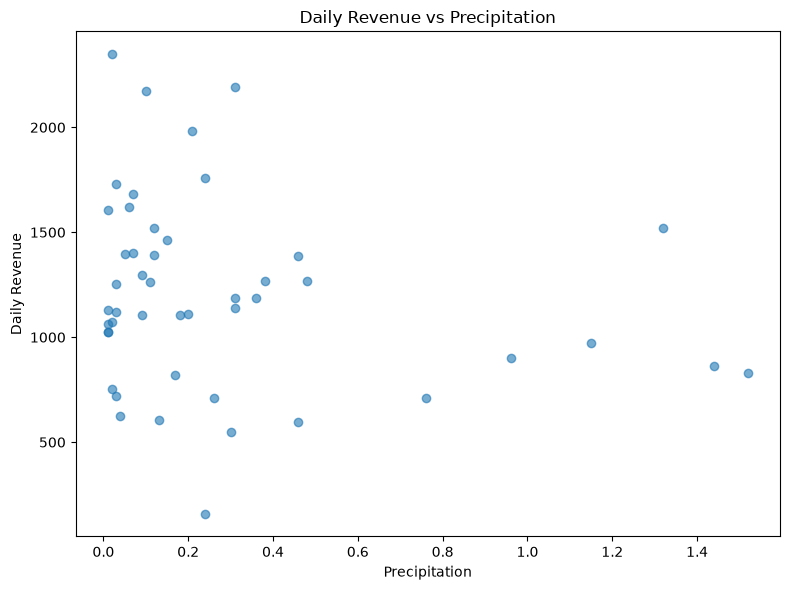

In [57]:
# Join precipitation with daily revenue by date
precip_revenue_df = (
    performance_stats 
    .join(
        rainy_days.select(F.to_date("DATE").alias("date"), F.col("PRCP")),
        on="date",
        how="inner"
    )
    .filter(F.col('PULocationID') == 119)
    .select("PRCP", "daily_revenue")
    .toPandas()
)

plt.figure(figsize=(8, 6))
plt.scatter(
    precip_revenue_df["PRCP"],
    precip_revenue_df["daily_revenue"],
    alpha=0.6
)
plt.xlabel("Precipitation")
plt.ylabel("Daily Revenue")
plt.title("Daily Revenue vs Precipitation")
plt.tight_layout()
plt.show()

In [62]:
# calculate percentage underperformance for location 119 
performance_stats_more = performance_stats.filter(F.col("PULocationID") == 119)  # Example PULocationID
performance_stats_more = performance_stats_more.withColumn(
    "underperformance_percentage",
    (F.col("expected_daily_revenue") - F.col("daily_revenue")) / F.col("expected_daily_revenue") * 100  # Convert to percentage
)
performance_stats_more.show()

+----------+------------+------------------+----------------------+---------------------------+
|      date|PULocationID|     daily_revenue|expected_daily_revenue|underperformance_percentage|
+----------+------------+------------------+----------------------+---------------------------+
|2026-01-01|         119|1583.6599999999999|    14560.467903225826|          89.12356381315777|
|2026-01-02|         119|           1225.38|     12211.57793388433|          89.96542456155603|
|2026-01-03|         119|            538.39|    12886.853153527007|          95.82217634060144|
|2026-01-04|         119| 778.6800000000001|    11649.236058091332|          93.31561317740535|
|2026-01-05|         119|1668.2700000000002|     11917.76881147546|          86.00182612710489|
|2026-01-06|         119|           1026.29|    12539.380040816339|          91.81546458708986|
|2026-01-07|         119|1128.6000000000001|     13247.79028925621|           91.4808434058978|
|2026-01-08|         119|           1416

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


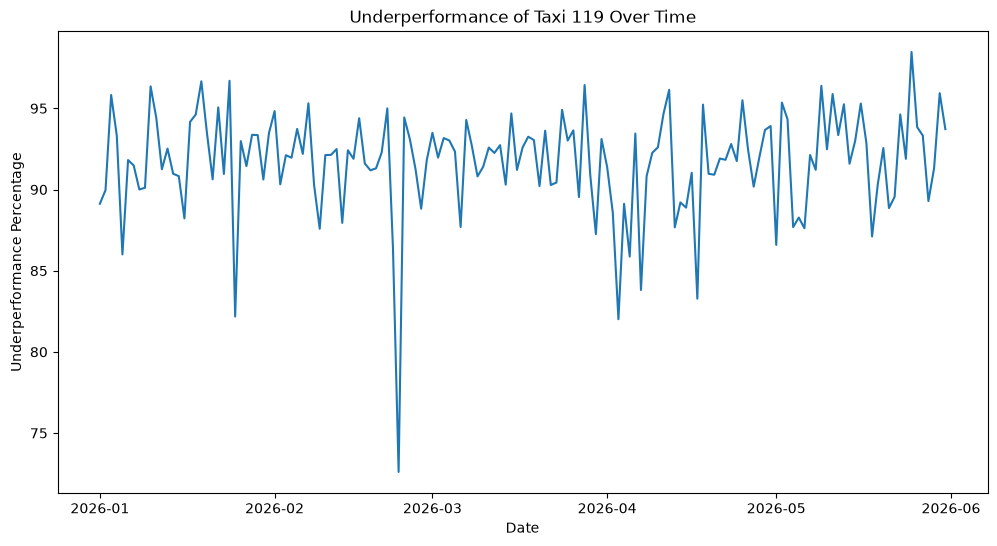

In [63]:
# make a line plot of the percentage underperformance over time for location 119
performance_stats_more_pd = performance_stats_more.select("date", "underperformance_percentage").orderBy("date").toPandas()

plt.figure(figsize=(12, 6))
plt.plot(performance_stats_more_pd["date"], performance_stats_more_pd["underperformance_percentage"])
plt.xlabel("Date")
plt.ylabel("Underperformance Percentage")
plt.title("Underperformance of Taxi 119 Over Time")
plt.show()

In [67]:
percentages = [row['underperformance_percentage'] for row in performance_stats_more.select('underperformance_percentage').collect()]
min_pct = min(percentages)
performance_stats_more.filter(F.col("underperformance_percentage") == min_pct).show()

+----------+------------+-----------------+----------------------+---------------------------+
|      date|PULocationID|    daily_revenue|expected_daily_revenue|underperformance_percentage|
+----------+------------+-----------------+----------------------+---------------------------+
|2026-02-23|         119|830.7800000000001|    3032.4754918032763|          72.60390060049676|
+----------+------------+-----------------+----------------------+---------------------------+



In [69]:
from datetime import datetime
weather_df.filter(F.col('date') == datetime(2026, 2, 23)).show()

+----------+----+----+----+----+----+
|      DATE|PRCP|SNOW|TMAX|TMIN|TAVG|
+----------+----+----+----+----+----+
|2026-02-23|1.52|15.3|  36|  29|32.5|
+----------+----+----+----+----+----+

